In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

df = pd.read_excel("ppp_bank_data_cleaned.xlsx")

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8943 entries, 0 to 8942
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   cust_id                           8943 non-null   str    
 1   balance                           8943 non-null   float64
 2   balance_frequency                 8943 non-null   float64
 3   purchases                         8943 non-null   float64
 4   oneoff_purchases                  8943 non-null   float64
 5   installments_purchases            8943 non-null   float64
 6   cash_advance                      8943 non-null   float64
 7   purchases_frequency               8943 non-null   float64
 8   oneoff_purchases_frequency        8943 non-null   float64
 9   purchases_installments_frequency  8943 non-null   float64
 10  cash_advance_frequency            8943 non-null   float64
 11  cash_advance_trx                  8943 non-null   int64  
 12  purchases_trx    

In [3]:
features = [
    "balance_frequency",
    "purchases_frequency",
    "purchases_trx",
    "purchases",
    "cash_advance_trx"
]
X = df[features]

In [4]:
# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

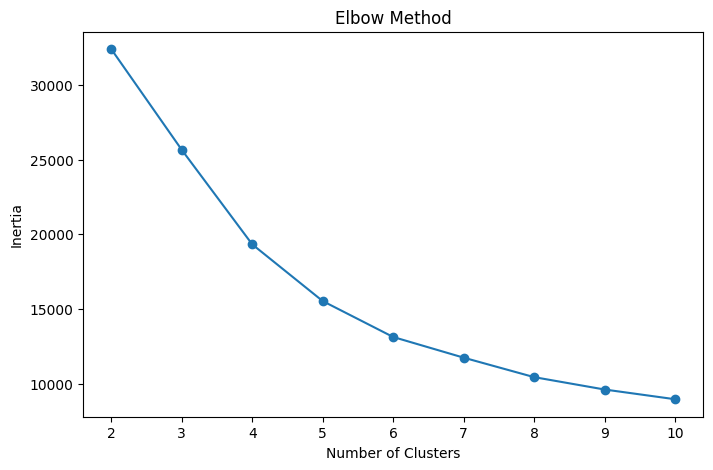

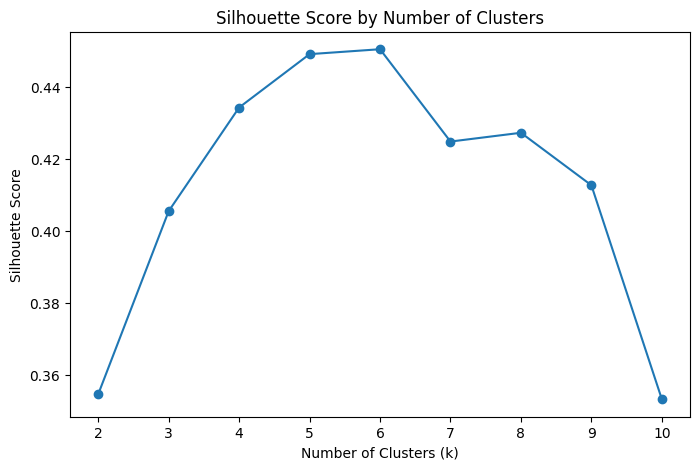

Clusters: 2, Silhouette Score: 0.3547
Clusters: 3, Silhouette Score: 0.4056
Clusters: 4, Silhouette Score: 0.4344
Clusters: 5, Silhouette Score: 0.4492
Clusters: 6, Silhouette Score: 0.4506
Clusters: 7, Silhouette Score: 0.4249
Clusters: 8, Silhouette Score: 0.4274
Clusters: 9, Silhouette Score: 0.4128
Clusters: 10, Silhouette Score: 0.3533

Selected number of clusters: 6


In [5]:
# Find optimal number of clusters
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nSelected number of clusters: {best_k}")


In [6]:
#Although k=6 gave the highest silhouette score, k=4 (or 5) was selected for better interpretability.
# Final model (k = 4 for interpretability)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [7]:
cluster_analysis = df.groupby("Cluster")[features].mean()
print(cluster_analysis)


         balance_frequency  purchases_frequency  purchases_trx    purchases  \
Cluster                                                                       
0                 0.967604             0.862123      21.704497  1315.585621   
1                 0.384382             0.281183       4.439232   354.919964   
2                 0.989324             0.961209     100.457766  7795.153215   
3                 0.969516             0.121815       2.169240   204.682668   

         cash_advance_trx  
Cluster                    
0                1.580567  
1                0.911158  
2                2.855586  
3                6.067288  


The clustering results reveal clear differences in customer activity levels. Cluster 1 represents highly active customers, with very high purchase frequency, transaction counts, and total spending. Cluster 2 includes active customers who use the service regularly, but at a lower intensity compared to Cluster 1.


Cluster 0 represents low-activity customers with minimal purchasing behaviour but the highest use of cash advances, indicating a reliance on credit rather than regular spending. Cluster 3 consists of the most passive customers, showing consistently low activity across all variables and the lowest engagement overall.


Overall, the clusters represent distinct levels of customer engagement, ranging from highly active users to low-engagement and credit-reliant customers.

In [8]:
# Namning clusters
cluster_names = {
    0: "Passive Credit Users",
    1: "Highly Active Users",
    2: "Active Users",
    3: "Passive Low Users"
}

df["Segment_Name"] = df["Cluster"].map(cluster_names)


In [9]:
# PCA visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

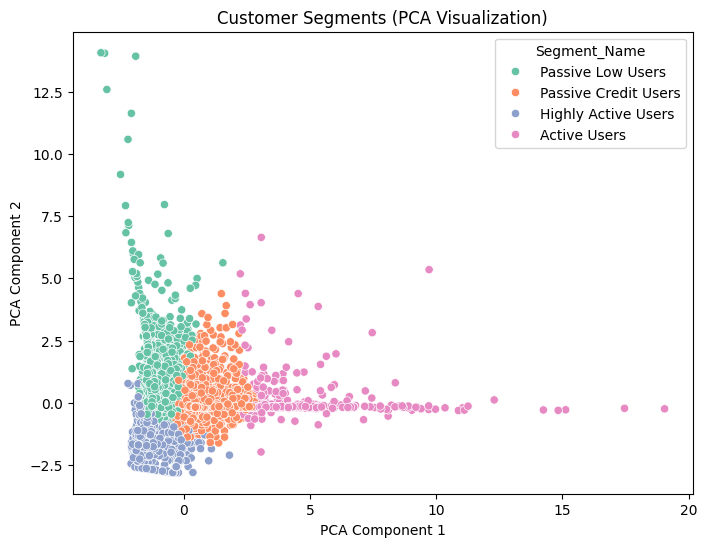

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Segment_Name",
    data=df,
    palette="Set2"
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

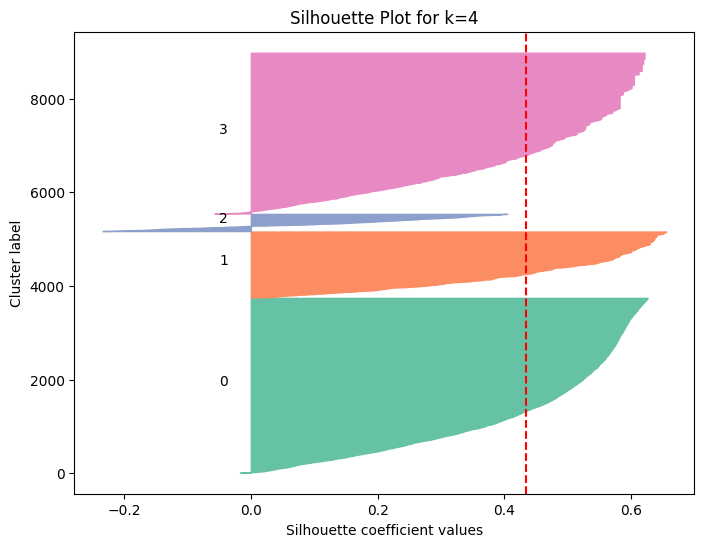

In [ ]:
# Silhouette plot per cluster (cluster quality and separation)
sample_silhouette_values = silhouette_samples(scaled_data, df["Cluster"])

y_lower = 10
n_clusters = 4

colors = sns.color_palette("Set2", n_clusters)

plt.figure(figsize=(8, 6))

for i in range(n_clusters):
    cluster_silhouette_values = sample_silhouette_values[df["Cluster"] == i]
    
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_values,
        color=colors[i]
    )
    
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10

plt.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")

plt.title("Silhouette Plot for k=4")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")

plt.show()

In [19]:
df.to_csv("ppp_final_bank_data_with_clusters.csv", index=False)

In [20]:
df.to_excel("ppp_final_bank_data_with_clusters.xlsx", index=False)